# Mamba State Analysis - Comprehensive Suite

This notebook consolidates all Mamba2 state analysis experiments:
- **Exp1**: Head heterogeneity & effective rank analysis
- **Exp2**: State similarity for semantic separability
- **Exp3**: State injection validation (enhanced with MSE)
- **Exp3-2**: State linearity tests (NEW)
- **Exp4**: Document position effect on QA (NEW)

Primary model: `state-spaces/mamba2-370m`

Forward-compatible design for Mamba3 when available.

## 0. Setup & Installation

In [2]:
# # Installation (run if needed)
# import sys, subprocess, os

# # 1. causal-conv1d
# subprocess.run([sys.executable, '-m', 'pip', 'install',
#               'git+https://github.com/Dao-AILab/causal-conv1d.git',
#               '--no-build-isolation'], check=True)

# # 2. mamba
# os.chdir('/root')
# subprocess.run(['rm', '-rf', 'mamba'], check=False)
# subprocess.run(['git', 'clone', 'https://github.com/state-spaces/mamba.git'],
# check=True)
# os.chdir('/root/mamba')

# env = os.environ.copy()
# env.update({'CAUSAL_CONV1D_FORCE_BUILD': 'TRUE',
#           'CAUSAL_CONV1D_SKIP_CUDA_BUILD': 'TRUE',
#           'CAUSAL_CONV1D_FORCE_CXX11_ABI': 'TRUE'})

# subprocess.run([sys.executable, '-m', 'pip', 'install',
# '--no-build-isolation', '.'],
#              env=env, check=True)
# print("✅ 완료")

# !pip install matplotlib seaborn scipy scikit-learn tqdm

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
from mamba_ssm.utils.generation import InferenceParams
from scipy.stats import ttest_rel, ttest_ind
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import json
import os
import warnings
warnings.filterwarnings('ignore')
from utils import effective_rank, get_ssm_states, get_A_disc, classify_heads, extract_state, inject_state_and_generate, compute_state_mse, compute_state_cosine, find_saturation_point, check_keywords, clear_memory   

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.09 GB


## 1. Model Configuration

In [18]:
# Model selection (enable/disable as needed)
MODEL_LIST = [
    # "state-spaces/mamba2-370m",     # Primary test model
    # "state-spaces/mamba2-130m",   # Uncomment to enable
    # "state-spaces/mamba2-780m",
    "state-spaces/mamba2-1.3b",
    # "state-spaces/mamba2-2.7b",
]

# Global parameters
T_RANGE = [32, 64, 128, 192, 256, 320, 384, 512, 768, 1024]
T_MAX = 1024
DOC_LEN = 256  # For exp2/exp3

# Head classification thresholds
SLOW_THRESHOLD = 0.99  # Type A
FAST_THRESHOLD = 0.50  # Type C

# Sampling
N_SAMPLES = 20
N_TOPICS = 5
N_DOCS_PER_TOPIC = 6
N_POSITION_DOCS = 10

# Results directory
RESULTS_DIR = "/root/smaller/mamba3_analysis/results"
PLOTS_DIR = f"{RESULTS_DIR}/plots"

# Create directories if they don't exist
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Models to analyze: {len(MODEL_LIST)}")
print(f"Primary model: {MODEL_LIST[0]}")
print(f"Results will be saved to: {RESULTS_DIR}")

Models to analyze: 1
Primary model: state-spaces/mamba2-1.3b
Results will be saved to: /root/smaller/mamba3_analysis/results


## 7. Experiment 3-2: State Linearity Tests

This experiment tests whether SSM state operations are linear/additive:

**Test cases**:
1. **Addition**: `state(doc1 + doc2) ≟ state(doc1) + state(doc2) - state(init)`
2. **Subtraction**: `state(doc1) ≟ state(doc1+doc2) - state(doc2) + state(init)`
3. **Weighted merge**: `state_merged = α·state(doc1) + (1-α)·state(doc2)`
4. **Generation quality**: Check if merged states produce coherent output

**Metrics**: MSE, cosine similarity, keyword matching

In [8]:
print("="*60)
print("Experiment 3-2: State Linearity Tests")
print("="*60)

LINEARITY_DOCS = [
  # ────────────────────────────────────────────────────────
  # Doc 0: 영어 자연어 (서술형)
  # ────────────────────────────────────────────────────────
  """The Apollo 11 mission was launched on July 16, 1969, and successfully
  landed humans on the Moon for the first time. Neil Armstrong and Buzz Aldrin

  walked on the lunar surface while Michael Collins orbited above. The mission

  demonstrated American space superiority during the Cold War era.""",

  # ────────────────────────────────────────────────────────
  # Doc 1: 수학 문제 (자연어 + 수식 혼합)
  # ────────────────────────────────────────────────────────
  """Problem: Find the derivative of f(x) = 3x² + 2x - 5.

  Solution: Using the power rule, f'(x) = d/dx(3x²) + d/dx(2x) - d/dx(5)
  = 6x + 2 - 0 = 6x + 2

  Therefore, f'(x) = 6x + 2.""",

  # ────────────────────────────────────────────────────────
  # Doc 2: 순수 수학 연산 (수식 위주)
  # ────────────────────────────────────────────────────────
  """Calculate:
  (15 + 23) × 4 - 18 ÷ 3 =
  38 × 4 - 6 =
  152 - 6 =
  146

  Matrix multiplication:
  [2 3] × [1 0] = [2+6  0+0] = [8  0]
  [4 1]   [2 0]   [4+2  0+0]   [6  0]""",

  # ────────────────────────────────────────────────────────
  # Doc 3: Python 코드
  # ────────────────────────────────────────────────────────
  """def fibonacci(n):
      if n <= 1:
          return n
      return fibonacci(n-1) + fibonacci(n-2)

  result = [fibonacci(i) for i in range(10)]
  print(result)  # [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]""",

  # ────────────────────────────────────────────────────────
  # Doc 4: 한국어
  # ────────────────────────────────────────────────────────
  """한글은 세종대왕이 1443년에 창제한 문자 체계입니다.
  과학적이고 체계적인 구조로 배우기 쉬우며, 24개의 자모로
  수천 개의 음절을 표현할 수 있습니다. 자음 14개와 모음 10개로
  구성되어 있으며, 표음문자이면서도 표의문자적 특성도 가지고 있습니다.""",

  # ────────────────────────────────────────────────────────
  # Doc 5: 중국어 (简体中文)
  # ────────────────────────────────────────────────────────
  """长城是中国古代的军事防御工程，建造历史超过两千年。
  最著名的部分由明朝建造，全长约21,196公里。
  长城主要用于防御北方游牧民族的入侵，
  是世界上最伟大的建筑奇迹之一，1987年被列入世界文化遗产。""",

  # ────────────────────────────────────────────────────────
  # Doc 6: 일본어
  # ────────────────────────────────────────────────────────
  """富士山は日本最高峰の独立峰で、標高3,776メートルです。
  古来より霊峰として崇められ、多くの芸術作品の題材となってきました。
  2013年にユネスコ世界文化遺産に登録されました。
  活火山であり、最後の噴火は1707年の宝永大噴火でした。""",

  # ────────────────────────────────────────────────────────
  # Doc 7: JSON / 구조화 데이터
  # ────────────────────────────────────────────────────────
  """{
    "employee": {
      "id": 12345,
      "name": "John Smith",
      "department": "Engineering",
      "skills": ["Python", "JavaScript", "SQL"],
      "salary": 85000,
      "active": true
    }
  }""",
]

print(f"Prepared {len(LINEARITY_DOCS)} diverse documents for testing")

Experiment 3-2: State Linearity Tests
Prepared 8 diverse documents for testing


In [7]:
# Use primary model
model_name = MODEL_LIST[0]
print(f"\\nLoading model: {model_name}")

model = model = MambaLMHeadModel.from_pretrained(model_name, device=device, dtype=torch.float32)
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
tokenizer.pad_token = tokenizer.eos_token


model.eval()
n_layers = len(model.backbone.layers)

print("Model loaded successfully!")

\nLoading model: state-spaces/mamba2-1.3b
Model loaded successfully!


In [9]:
def state_add(state1, state2, weight2=1.0, state_init=None):
    """
    Add two states: state1 + weight2 * state2 - state_init

    Args:
        state1, state2: state dictionaries
        weight2: weight for state2 (default 1.0)
        state_init: initial state to subtract (for proper addition)

    Returns:
        dict: merged state
        """

    merged = {}
    for layer_idx in state1.keys():
        if layer_idx in state2:
            merged_layer = state1[layer_idx] + weight2 * state2[layer_idx]
            if state_init is not None and layer_idx in state_init:
                merged_layer = merged_layer - state_init[layer_idx]
            merged[layer_idx] = merged_layer
    return merged

def state_subtract(state1, state2, state_init=None):
    """
    Subtract states: state1 - state2 + state_init
    """
    diff = {}
    for layer_idx in state1.keys():
        if layer_idx in state2:
            diff_layer = state1[layer_idx] - state2[layer_idx]
            if state_init is not None and layer_idx in state_init:
                diff_layer = diff_layer + state_init[layer_idx]
            diff[layer_idx] = diff_layer
    return diff

def weighted_merge(state1, state2, alpha):
    """
    Weighted merge: alpha * state1 + (1-alpha) * state2
    """
    merged = {}
    for layer_idx in state1.keys():
        if layer_idx in state2:
            merged[layer_idx] = alpha * state1[layer_idx] + (1 - alpha) * state2[layer_idx]
    return merged

print("State operation functions defined.")

State operation functions defined.


### 7.2 Test Case 1: Addition

In [11]:
print("\\n" + "="*50)
print("Test Case 1: Addition")
print("="*50)
print("Hypothesis: state(doc1 + doc2) ≈ state(doc1) + state(doc2) - state(init)")
print()

# Extract initial state (empty input)
# empty string 대신 zeros로 init state 정의
def get_zero_state(model, device):
    state = {}
    for layer_idx, layer in enumerate(model.backbone.layers):
        if hasattr(layer, 'mixer') and hasattr(layer.mixer, 'A_log'):
            n_heads  = layer.mixer.A_log.shape[0]
            headdim  = layer.mixer.headdim
            d_state  = layer.mixer.d_state
            state[layer_idx] = torch.zeros(n_heads, headdim, d_state, device='cpu')
    return state

state_init = get_zero_state(model, device)

# Test 5 document pairs
addition_pairs = [(0,1), (2,3), (4,5), (6,7), (0,7)]
addition_results = []

for pair_idx, (doc_i, doc_j) in enumerate(addition_pairs):
    print(f"\\nPair {pair_idx + 1}: Doc {doc_i} + Doc {doc_j}")

    doc1 = LINEARITY_DOCS[doc_i]
    doc2 = LINEARITY_DOCS[doc_j]
    combined = doc1 + " " + doc2

    # Extract states
    state1 = extract_state(model, tokenizer, doc1, device=device)
    state2 = extract_state(model, tokenizer, doc2, device=device)
    state_combined_true = extract_state(model, tokenizer, combined, device=device)

    # Linear prediction
    state_combined_pred = state_add(state1, state2, 1.0, state_init)

    # Compute metrics
    mse_per_layer, mean_mse = compute_state_mse(state_combined_true, state_combined_pred)
    cos_per_layer, mean_cos = compute_state_cosine(state_combined_true, state_combined_pred)

    print(f"  MSE: {mean_mse:.6f}")
    print(f"  Cosine: {mean_cos:.4f}")

    # Generation test
    query = "Summarize the context: "

    # True combined state generation
    gen_true = inject_state_and_generate(model, tokenizer, query, state_combined_true, max_new_tokens=40, device=device)
    gen_true_only = gen_true[len(query):].strip()

    # Predicted combined state generation
    gen_pred = inject_state_and_generate(model, tokenizer, query, state_combined_pred, max_new_tokens=40, device=device)
    gen_pred_only = gen_pred[len(query):].strip()

    print(f"  True gen: {gen_true_only[:60]}...")
    print(f"  Pred gen: {gen_pred_only[:60]}...")

    # Check if generations mention both topics
    # Extract key topic words from each doc
    doc1_keywords = set(doc1.lower().split()[:5])  # Simple heuristic
    doc2_keywords = set(doc2.lower().split()[:5])

    gen_true_words = set(gen_true_only.lower().split())
    gen_pred_words = set(gen_pred_only.lower().split())

    match_true = len(doc1_keywords & gen_true_words) + len(doc2_keywords & gen_true_words)
    match_pred = len(doc1_keywords & gen_pred_words) + len(doc2_keywords & gen_pred_words)

    print(f"  Keyword matches - True: {match_true}, Pred: {match_pred}")

    addition_results.append({
        'pair': (doc_i, doc_j),
        'mse': mean_mse,
        'cosine': mean_cos,
        'gen_true': gen_true_only,
        'gen_pred': gen_pred_only,
        'match_true': match_true,
        'match_pred': match_pred,
    })

print("\\nAddition test complete!")

\n==================================================
Test Case 1: Addition
Hypothesis: state(doc1 + doc2) ≈ state(doc1) + state(doc2) - state(init)

\nPair 1: Doc 0 + Doc 1
  MSE: 0.002424
  Cosine: 0.8701
  True gen: fore, f(x) = 6x + 2

  Therefore, f(x) = 6x + 2

  Therefore...
  Pred gen: ...
  Keyword matches - True: 0, Pred: 0
\nPair 2: Doc 2 + Doc 3
  MSE: 0.002137
  Cosine: 0.9021
  True gen: , 13, 21, 34]

A:

You can use the numpy.linalg.matrix...
  Pred gen: if n <= 1:
        return n
    return fibonacci(n-1) + fibo...
  Keyword matches - True: 0, Pred: 4
\nPair 3: Doc 4 + Doc 5
  MSE: 0.001617
  Cosine: 0.9000
  True gen: 千年。...
  Pred gen: 的军事防御工程
  -...
  Keyword matches - True: 0, Pred: 0
\nPair 4: Doc 6 + Doc 7
  MSE: 0.001624
  Cosine: 0.8247
  True gen: following code to get the employee id and name:
import json
...
  Pred gen: ...
  Keyword matches - True: 0, Pred: 0
\nPair 5: Doc 0 + Doc 7
  MSE: 0.002380
  Cosine: 0.8195
  True gen: mployee id and name from the a

### 7.3 Test Case 2: Subtraction

In [12]:
print("\\n" + "="*50)
print("Test Case 2: Subtraction")
print("="*50)
print("Hypothesis: state(doc1) ≈ state(doc1+doc2) - state(doc2) + state(init)")
print()

# Test 3 document pairs
subtraction_pairs = [(0,1), (2,3), (4,5)]
subtraction_results = []

for pair_idx, (doc_i, doc_j) in enumerate(subtraction_pairs):
    print(f"\\nPair {pair_idx + 1}: Extract Doc {doc_i} from (Doc {doc_i} + Doc {doc_j})")

    doc1 = LINEARITY_DOCS[doc_i]
    doc2 = LINEARITY_DOCS[doc_j]
    combined = doc1 + " " + doc2

    # Extract states
    state1_true = extract_state(model, tokenizer, doc1, device=device)
    state2 = extract_state(model, tokenizer, doc2, device=device)
    state_combined = extract_state(model, tokenizer, combined, device=device)

    # Subtraction: try to recover doc1 from combined
    state1_pred = state_subtract(state_combined, state2, state_init)

    # Compute metrics
    mse_per_layer, mean_mse = compute_state_mse(state1_true, state1_pred)
    cos_per_layer, mean_cos = compute_state_cosine(state1_true, state1_pred)

    print(f"  MSE: {mean_mse:.6f}")
    print(f"  Cosine: {mean_cos:.4f}")

    # Generation test: Does reconstructed state produce doc1 content?
    query = "What was in the context?"

    gen_true = inject_state_and_generate(model, tokenizer, query, state1_true, max_new_tokens=40, device=device)
    gen_true_only = gen_true[len(query):].strip()

    gen_pred = inject_state_and_generate(model, tokenizer, query, state1_pred, max_new_tokens=40, device=device)
    gen_pred_only = gen_pred[len(query):].strip()

    print(f"  True gen: {gen_true_only[:60]}...")
    print(f"  Pred gen: {gen_pred_only[:60]}...")

    # Check if doc1 content is preserved
    doc1_keywords = set(doc1.lower().split()[:8])
    match_true = len(doc1_keywords & set(gen_true_only.lower().split()))
    match_pred = len(doc1_keywords & set(gen_pred_only.lower().split()))

    print(f"  Doc1 keyword matches - True: {match_true}, Pred: {match_pred}")

    subtraction_results.append({
        'pair': (doc_i, doc_j),
        'mse': mean_mse,
        'cosine': mean_cos,
        'gen_true': gen_true_only,
        'gen_pred': gen_pred_only,
        'match_true': match_true,
        'match_pred': match_pred,
    })

print("\\nSubtraction test complete!")

\n==================================================
Test Case 2: Subtraction
Hypothesis: state(doc1) ≈ state(doc1+doc2) - state(doc2) + state(init)

\nPair 1: Extract Doc 0 from (Doc 0 + Doc 1)
  MSE: 0.002424
  Cosine: 0.3629
  True gen: ion was launched on July 16, 1969, and successfully
  landed...
  Pred gen: ion was launched on July 16, 1969, and successfully landed h...
  Doc1 keyword matches - True: 5, Pred: 5
\nPair 2: Extract Doc 2 from (Doc 2 + Doc 3)
  MSE: 0.002137
  Cosine: 0.3444
  True gen: 0+0]   [6  0]   [8  0]
  [4 1]...
  Pred gen: ication is correct.
The matrix multiplication is defined as:...
  Doc1 keyword matches - True: 0, Pred: 0
\nPair 3: Extract Doc 4 from (Doc 4 + Doc 5)
  MSE: 0.001617
  Cosine: 0.3481
  True gen: 3년...
  Pred gen: t you are using the same variable name for the two different...
  Doc1 keyword matches - True: 0, Pred: 0
\nSubtraction test complete!


### 7.4 Test Case 3: Weighted Merge

In [13]:
print("\\n" + "="*50)
print("Test Case 3: Weighted Merge")
print("="*50)
print("Hypothesis: α controls information balance in merged state")
print()

# Test 3 pairs × 3 alpha values
weighted_pairs = [(0,1), (2,3), (4,5)]
alphas = [0.3, 0.5, 0.7]
weighted_results = []

for pair_idx, (doc_i, doc_j) in enumerate(weighted_pairs):
    print(f"\\n--- Pair {pair_idx + 1}: Doc {doc_i} + Doc {doc_j} ---")

    doc1 = LINEARITY_DOCS[doc_i]
    doc2 = LINEARITY_DOCS[doc_j]

    state1 = extract_state(model, tokenizer, doc1, device=device)
    state2 = extract_state(model, tokenizer, doc2, device=device)

    # Create questions about each document
    query1 = f"What is the main topic of the first document?"
    query2 = f"What is the main topic of the second document?"

    for alpha in alphas:
        print(f"\\n  Alpha = {alpha}")

        # Weighted merge
        state_merged = weighted_merge(state1, state2, alpha)

        # Query both documents
        ans1 = inject_state_and_generate(model, tokenizer, query1, state_merged, max_new_tokens=30, device=device)
        ans1_only = ans1[len(query1):].strip()

        ans2 = inject_state_and_generate(model, tokenizer, query2, state_merged, max_new_tokens=30, device=device)
        ans2_only = ans2[len(query2):].strip()

        print(f"    Doc1 answer: {ans1_only[:50]}...")
        print(f"    Doc2 answer: {ans2_only[:50]}...")

        # Score: Does answer quality match alpha weighting?
        doc1_keywords = set(doc1.lower().split()[:8])
        doc2_keywords = set(doc2.lower().split()[:8])

        score1 = len(doc1_keywords & set(ans1_only.lower().split()))
        score2 = len(doc2_keywords & set(ans2_only.lower().split()))

        print(f"    Scores - Doc1: {score1}, Doc2: {score2}")

        # Expected: higher alpha → better score1
        weighted_results.append({
            'pair': (doc_i, doc_j),
            'alpha': alpha,
            'ans1': ans1_only,
            'ans2': ans2_only,
            'score1': score1,
            'score2': score2,
        })

print("\\nWeighted merge test complete!")

\n==================================================
Test Case 3: Weighted Merge
Hypothesis: α controls information balance in merged state

\n--- Pair 1: Doc 0 + Doc 1 ---
\n  Alpha = 0.3
    Doc1 answer: $ is $f'(x...
    Doc2 answer: is $f'(x...
    Scores - Doc1: 0, Doc2: 0
\n  Alpha = 0.5
    Doc1 answer: derivative of $f(x) = 3x^2 + 2x -...
    Doc2 answer: The derivative...
    Scores - Doc1: 0, Doc2: 2
\n  Alpha = 0.7
    Doc1 answer: the article.
The article is titled "The Apollo 11 ...
    Doc2 answer: the question "What is the answer to the question '...
    Scores - Doc1: 3, Doc2: 1
\n--- Pair 2: Doc 2 + Doc 3 ---
\n  Alpha = 0.3
    Doc1 answer: # 1
  print(result[2])...
    Doc2 answer: 1
  print(result[2])...
    Scores - Doc1: 0, Doc2: 0
\n  Alpha = 0.5
    Doc1 answer: ...
    Doc2 answer: ...
    Scores - Doc1: 0, Doc2: 0
\n  Alpha = 0.7
    Doc1 answer: ...
    Doc2 answer: ...
    Scores - Doc1: 0, Doc2: 0
\n--- Pair 3: Doc 4 + Doc 5 ---
\n  Alpha = 0.3
    Doc1 ans

### 7.6 Visualization

\nGenerating visualizations...
Saved to /root/smaller/mamba3_analysis/results/plots/exp3_2_addition_mse.png


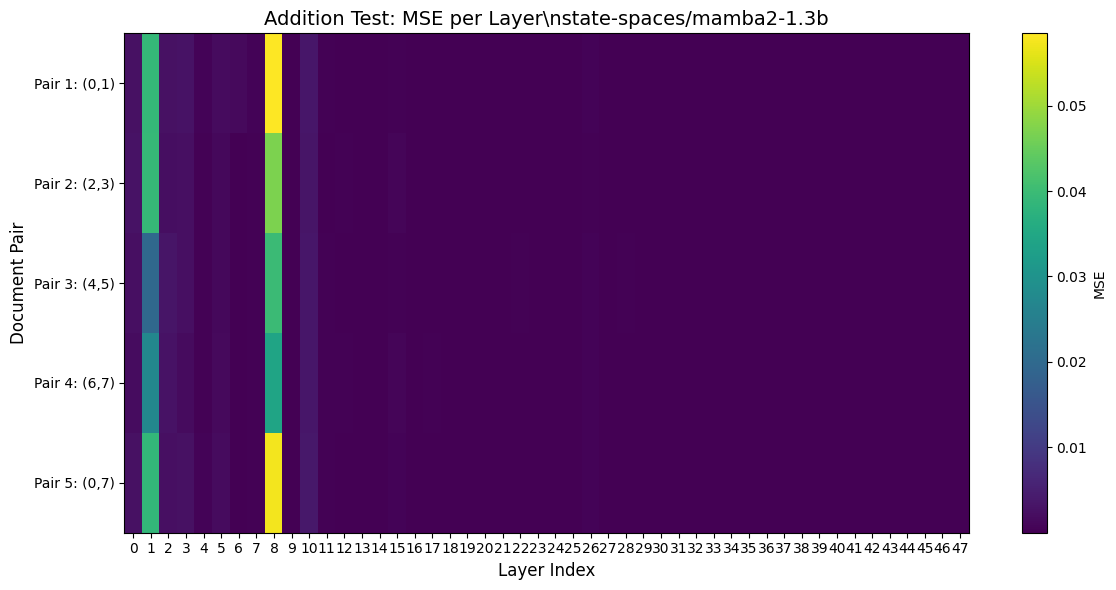

In [19]:
print("\\nGenerating visualizations...")

# Heatmap 1: Addition test MSE (pairs × layers)
# Extract MSE per layer for each pair
addition_mse_matrix = np.zeros((len(addition_pairs), n_layers))

for pair_idx, (doc_i, doc_j) in enumerate(addition_pairs):
    doc1 = LINEARITY_DOCS[doc_i]
    doc2 = LINEARITY_DOCS[doc_j]
    combined = doc1 + " " + doc2

    state1 = extract_state(model, tokenizer, doc1, device=device)
    state2 = extract_state(model, tokenizer, doc2, device=device)
    state_combined_true = extract_state(model, tokenizer, combined, device=device)
    state_combined_pred = state_add(state1, state2, 1.0, state_init)

    mse_per_layer, _ = compute_state_mse(state_combined_true, state_combined_pred)

    for layer_idx, mse_val in mse_per_layer.items():
        addition_mse_matrix[pair_idx, layer_idx] = mse_val

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(addition_mse_matrix, cmap='viridis', aspect='auto')
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Document Pair', fontsize=12)
ax.set_title(f'Addition Test: MSE per Layer\\n{model_name}', fontsize=14)
ax.set_yticks(range(len(addition_pairs)))
ax.set_yticklabels([f'Pair {i+1}: ({p[0]},{p[1]})' for i, p in enumerate(addition_pairs)])
ax.set_xticks(range(n_layers))
plt.colorbar(im, ax=ax, label='MSE')

plt.tight_layout()
save_path = f"{PLOTS_DIR}/exp3_2_addition_mse.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

Saved to /root/smaller/mamba3_analysis/results/plots/exp3_2_mse_by_operation.png


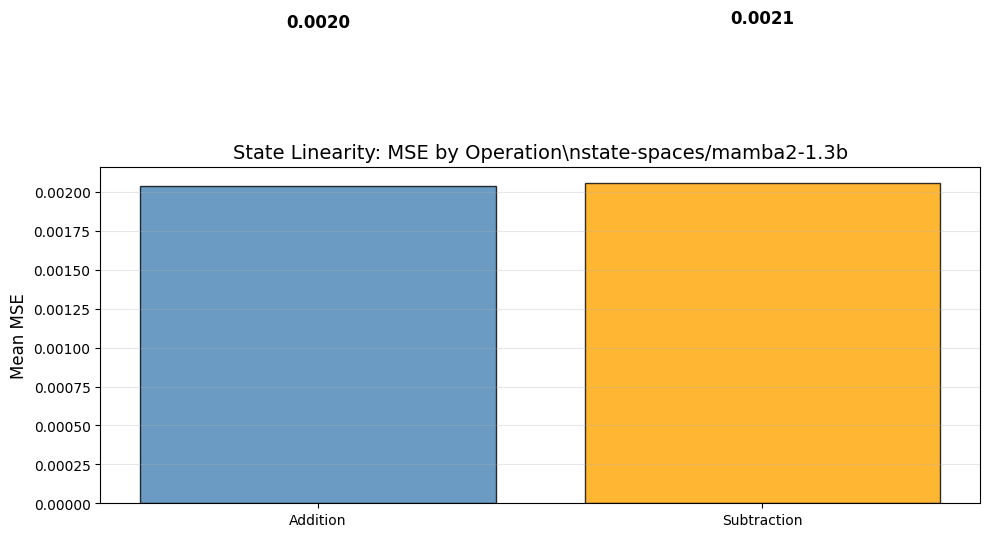

In [20]:
# Bar chart: Mean MSE by operation type
fig, ax = plt.subplots(figsize=(10, 6))

operations = ['Addition', 'Subtraction']
mean_mses = [
    np.mean([r['mse'] for r in addition_results]),
    np.mean([r['mse'] for r in subtraction_results])
]

bars = ax.bar(operations, mean_mses, color=['steelblue', 'orange'], alpha=0.8, edgecolor='black')

for bar, mse in zip(bars, mean_mses):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.001, f'{mse:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Mean MSE', fontsize=12)
ax.set_title(f'State Linearity: MSE by Operation\\n{model_name}', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = f"{PLOTS_DIR}/exp3_2_mse_by_operation.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

Saved to /root/smaller/mamba3_analysis/results/plots/exp3_2_weighted_alpha.png


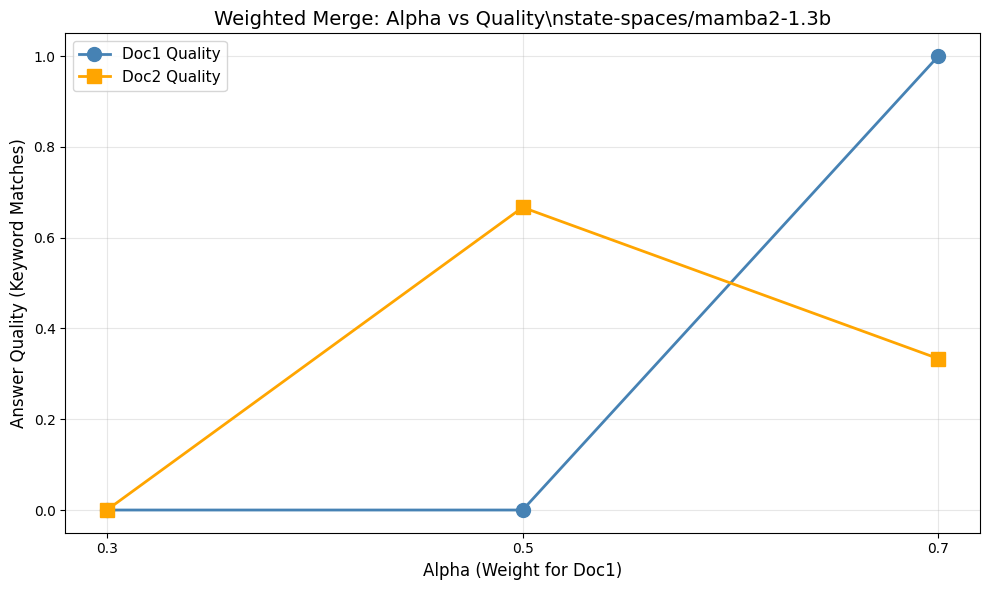

In [21]:
# Line plot: Alpha vs Answer Quality
fig, ax = plt.subplots(figsize=(10, 6))

# Aggregate scores by alpha
alpha_values = sorted(set(r['alpha'] for r in weighted_results))
score1_by_alpha = {a: [] for a in alpha_values}
score2_by_alpha = {a: [] for a in alpha_values}

for r in weighted_results:
    score1_by_alpha[r['alpha']].append(r['score1'])
    score2_by_alpha[r['alpha']].append(r['score2'])

mean_score1 = [np.mean(score1_by_alpha[a]) for a in alpha_values]
mean_score2 = [np.mean(score2_by_alpha[a]) for a in alpha_values]

ax.plot(alpha_values, mean_score1, 'o-', linewidth=2, markersize=10, label='Doc1 Quality', color='steelblue')
ax.plot(alpha_values, mean_score2, 's-', linewidth=2, markersize=10, label='Doc2 Quality', color='orange')

ax.set_xlabel('Alpha (Weight for Doc1)', fontsize=12)
ax.set_ylabel('Answer Quality (Keyword Matches)', fontsize=12)
ax.set_title(f'Weighted Merge: Alpha vs Quality\\n{model_name}', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xticks(alpha_values)

plt.tight_layout()
save_path = f"{PLOTS_DIR}/exp3_2_weighted_alpha.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

In [22]:
exp3_2_results = {
    'addition': addition_results,
    'subtraction': subtraction_results,
    'weighted': weighted_results,
}

with open(f"{RESULTS_DIR}/exp3_2_linearity.json", 'w') as f:
    # Convert numpy types
    save_dict = {}
    for key, results in exp3_2_results.items():
        save_dict[key] = []
        for r in results:
            r_copy = r.copy()
            for k, v in r_copy.items():
                if isinstance(v, (np.int64, np.int32)):
                    r_copy[k] = int(v)
                elif isinstance(v, (np.float64, np.float32)):
                    r_copy[k] = float(v)
            save_dict[key].append(r_copy)

    json.dump(save_dict, f, indent=2)

print(f"\\nResults saved to {RESULTS_DIR}/exp3_2_linearity.json")
print("\\nExperiment 3-2 complete!")

\nResults saved to /root/smaller/mamba3_analysis/results/exp3_2_linearity.json
\nExperiment 3-2 complete!
